**Import Optimizers**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Build and compile the ANN**

In [8]:
# Build and compile the ANN

def build_model(optimizer):

    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


optimizers = {
    "SGD": SGD(),
    "Momentum": SGD(momentum=0.9),
    "RMSprop": RMSprop(),
    "Adam": Adam()
}

history_dict_C = {}
evaluation_dict_C = {}

**Train the ANN**

In [9]:
# Train the ANN

for name, optimizer in optimizers.items():

    print("-" * 50)
    print(f"Training with {name}")
    print("-" * 50)

    model = build_model(optimizer)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    history_dict_C[name] = history

    evaluation_dict_C[name] = {
        "loss": loss,
        "accuracy": accuracy
    }

    print(f"\n{name} Results")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy:.4f}\n")

--------------------------------------------------
Training with SGD
--------------------------------------------------
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8300 - loss: 0.6352 - val_accuracy: 0.9101 - val_loss: 0.3194
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9143 - loss: 0.2995 - val_accuracy: 0.9265 - val_loss: 0.2574
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9282 - loss: 0.2499 - val_accuracy: 0.9374 - val_loss: 0.2247
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9375 - loss: 0.2176 - val_accuracy: 0.9425 - val_loss: 0.1998
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9458 - loss: 0.1922 - val_accuracy: 0.9466 - val_loss: 0.1829
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9511 - loss: 0.1714 - val_accuracy: 0.9533 - val_loss: 0.1637
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9555 - loss: 0.1543 - val_accura

**Comparison Table**

In [10]:
# Optimizer Comparison

print("\nOptimizer Comparison")
print("-" * 50)

for name in optimizers.keys():

    print(
        f"{name:10} "
        f"Accuracy : {evaluation_dict_C[name]['accuracy']:.4f} | "
        f"Loss : {evaluation_dict_C[name]['loss']:.4f}"
    )


Optimizer Comparison
--------------------------------------------------
SGD        Accuracy : 0.9651 | Loss : 0.1247
Momentum   Accuracy : 0.9754 | Loss : 0.0865
RMSprop    Accuracy : 0.9783 | Loss : 0.1105
Adam       Accuracy : 0.9767 | Loss : 0.0987


**Visualizations**

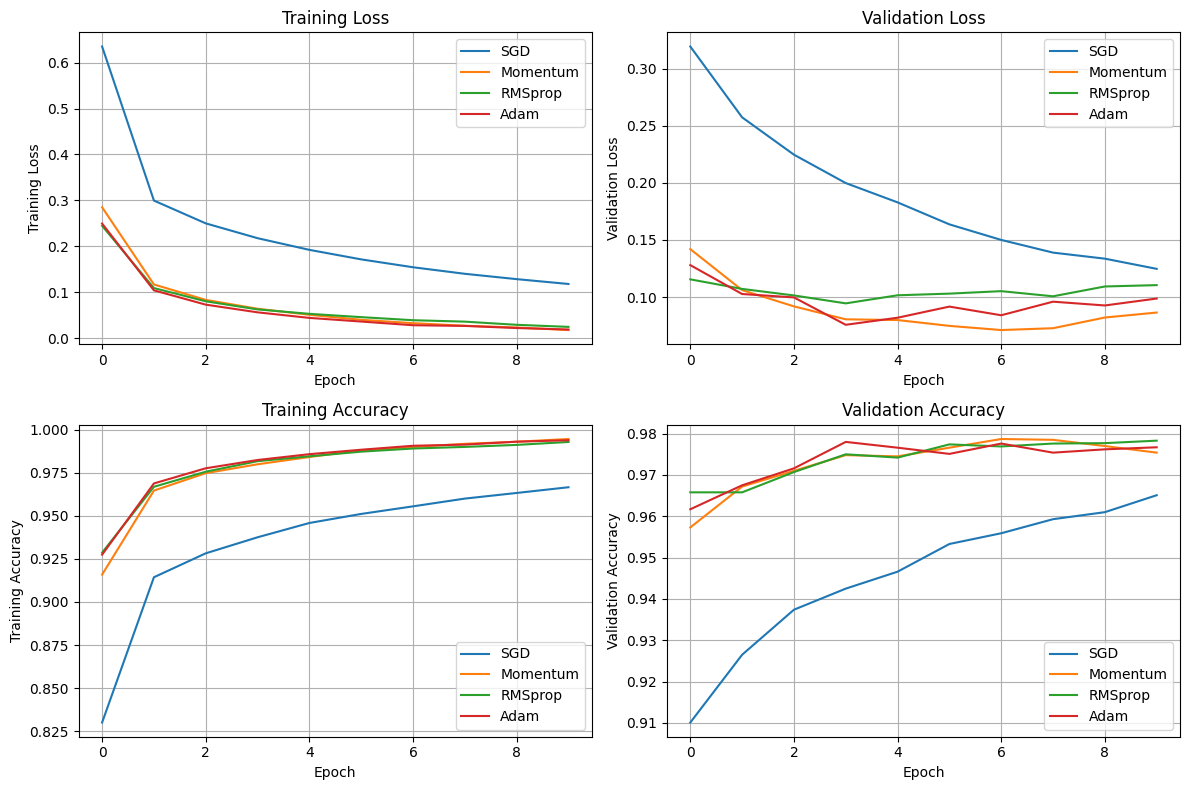

In [11]:
# Plot training and validation graphs

metrics = [
    ('loss', 'Training Loss'),
    ('val_loss', 'Validation Loss'),
    ('accuracy', 'Training Accuracy'),
    ('val_accuracy', 'Validation Accuracy')
]

plt.figure(figsize=(12, 8))

for i, (metric, title) in enumerate(metrics, 1):

    plt.subplot(2, 2, i)

    for name, h in history_dict_C.items():
        plt.plot(
            h.history[metric],
            label=name
        )

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(title)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()